In [1]:
# Run this cell to set up packages for lecture.
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
from IPython.display import display, IFrame

path = 'lectures/lec06'
if not Path("data").exists():
    !wget -q -O /content/course.zip https://github.com/dsc-courses/cosmos-ml-cluster-2026/archive/refs/heads/main.zip
    !unzip -q -o /content/course.zip "cosmos-ml-cluster-2026-main/{path}/data/*" -d /content/course-assets
    !cp -R /content/course-assets/cosmos-ml-cluster-2026-main/{path}/data .

plt.style.use('seaborn-v0_8-colorblind')
plt.rcParams.update({
    'figure.figsize': (10, 5),
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'axes.labelweight': 'bold',
    'axes.linewidth': 1.5,
    'grid.color': '#999999',
    'grid.alpha': 0.6,
    'font.weight': 'bold',
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'xtick.major.width': 1.2,
    'ytick.major.width': 1.2,
    'xtick.color': 'black',
    'ytick.color': 'black',
    'legend.fontsize': 11,
    'legend.title_fontsize': 12,
})

np.set_printoptions(threshold=20, precision=2, suppress=True)
pd.set_option("display.max_rows", 7)
pd.set_option("display.max_columns", 8)
pd.set_option("display.precision", 2)

def merging_animation():
    src = "https://docs.google.com/presentation/d/1d0G-_P6pLWK83wW3wPetGfzLADRqxO3jO0thK7lhtSE/embed?start=false&loop=false&delayms=3000&rm=minimal"
    width = 825
    height = 500
    display(IFrame(src, width, height))

def concept_check():
    src = "https://docs.google.com/presentation/d/1V0d5kNVWmalLY0SkzZzKDDc_3CDZSE5m6Av0gC-PfJo/embed?start=false&loop=false&delayms=3000&rm=minimal"
    width = 825
    height = 500
    display(IFrame(src, width, height))


# Lecture 6 - Grouping on Multiple Columns, Merging

## COSMOS ML Cluster 2026


### Agenda

- Grouping on multiple columns.
- Merging.

## Grouping on multiple columns

### Sample student data

We'll start from the sample roster from last lecture, with each student's first name already extracted.


In [2]:
roster = pd.read_csv('data/roster-anon.csv')

def first_name(full_name):
    '''Returns the first name given a full name.'''
    return full_name.split(' ')[0]

roster = roster.assign(
    first=roster.get('name').apply(first_name)
)
roster


,name,section,first
0,Camilla Ozqcfu,B,Camilla
1,Yifan Ignjpe,A,Yifan
2,Ali Jjsojh,A,Ali
...,...,...,...
491,Qiankang Tzjsbb,D,Qiankang
492,Kim Wxnmuh,C,Kim
493,Jazmine Sxcvft,C,Jazmine


### Grouping on multiple columns

In [3]:
roster

,name,section,first
0,Camilla Ozqcfu,B,Camilla
1,Yifan Ignjpe,A,Yifan
2,Ali Jjsojh,A,Ali
...,...,...,...
491,Qiankang Tzjsbb,D,Qiankang
492,Kim Wxnmuh,C,Kim
493,Jazmine Sxcvft,C,Jazmine


We can pass a **list** of column names to `.groupby`!

In [4]:
roster.groupby(['section', 'first']).count()

name
section first         
A       Aayushi      1
        Abhinav      1
        Abhishai     1
...                ...
D       Yuting       1
        Zhexuan      1
        Zhong        1

[468 rows x 1 columns]

The above DataFrame is telling us, for instance, that there is 1 student with the first name `'Aayushi'` in section A.

It is **not** saying that there is only one `'Aayushi'` in the course overall. There could be more in the other sections.

### Grouping on multiple columns

- To group on multiple columns, pass a **list** of column names to `.groupby`:

<br>

<center><code>df.groupby(['col_1', 'col_2', ..., 'col_k'])</code></center>


- Group by `'col_1'` first. **Within each group**, group by `'col_2'`, and so on.

- **Important: The resulting DataFrame has one row per unique combination of entries in the specified columns.**
    - On the previous slide, we had exactly one row for every combination of `'section'` and `'first'`.

- Formally, when we group on multiple columns, we are creating _subgroups_ – that is, **groups within groups**.
    - On the previous slide, we first grouped by `'section'`, and within each section, we grouped by `'first'`.

### Notice the index... 🤔

- This is called a "[MultiIndex](https://pandas.pydata.org/pandas-docs/stable/user_guide/advanced.html)".
    - The DataFrame is indexed by `'section'` **and** `'first'`.
- We won't worry about the details of MultiIndexes.
- We can use `.reset_index()` to "flatten" our DataFrame back to normal.

In [5]:
roster.groupby(['section', 'first']).count().reset_index()

,section,first,name
0,A,Aayushi,1
1,A,Abhinav,1
2,A,Abhishai,1
...,...,...,...
465,D,Yuting,1
466,D,Zhexuan,1
467,D,Zhong,1


### Does order matter?

In [6]:
roster.groupby(['section', 'first']).count().reset_index()

,section,first,name
0,A,Aayushi,1
1,A,Abhinav,1
2,A,Abhishai,1
...,...,...,...
465,D,Yuting,1
466,D,Zhexuan,1
467,D,Zhong,1


In [7]:
roster.groupby(['first', 'section']).count().reset_index()

,first,section,name
0,Aarush,C,1
1,Aayushi,A,1
2,Abhinav,A,1
...,...,...,...
465,Zichen,B,1
466,Zixiang,B,1
467,Ziyong,A,1


**Answer**: Kind of. The order of the rows and columns will be different, but the content will be the same.

### Activity

1. Using `counts`, find the section with the most `'Daniel'`s.
2. Using `counts`, find the longest first name in the class that is shared by at least two students in the same section.

<details>
<summary>✅ Click <b>here</b> to see the solutions <b>after</b> you've tried both problems.</summary>
    
<pre>

daniel_counts = counts[counts.get('first') == 'Daniel']
daniel_counts.sort_values('name', ascending=False).get('section').iloc[0]

with_len = counts.assign(length=counts.get('first').apply(len))
with_len[with_len.get('name') >= 2].sort_values('length', ascending=False).get('first').iloc[0]

</pre>
        
</details>

In [8]:
counts = roster.groupby(['section', 'first']).count().reset_index()
counts

,section,first,name
0,A,Aayushi,1
1,A,Abhinav,1
2,A,Abhishai,1
...,...,...,...
465,D,Yuting,1
466,D,Zhexuan,1
467,D,Zhong,1


### Example: Sea temperatures 🌊

[This dataset](https://library.ucsd.edu/dc/object/bb4003017c) contains the sea surface temperature in La Jolla, on many days ranging from August 22, 1916 to June 30, 2025.

In [9]:
sea_temp = pd.read_csv('data/sea_temp.csv')
sea_temp

,YEAR,MONTH,DAY,SURFACE_TEMP
0,1916,8,22,19.5
1,1916,8,23,19.9
2,1916,8,24,19.7
...,...,...,...,...
38440,2025,6,28,22.1
38441,2025,6,29,21.7
38442,2025,6,30,20.4


### Concept Check ✅

We want to find the single month (e.g. November 1998) with the highest average `'SURFACE_TEMP'`.

Which of the following would help us achieve this goal?

A. `sea_temp.groupby('SURFACE_TEMP').mean()`

B. `sea_temp.groupby('MONTH').mean()`

C. `sea_temp.groupby(['YEAR', 'MONTH']).mean()`

D. `sea_temp.groupby(['MONTH', 'DAY']).mean()`

E. `sea_temp.groupby(['MONTH', 'SURFACE_TEMP']).mean()`

In [10]:
...

Ellipsis

### Plots of monthly and yearly average surface temperature 📈

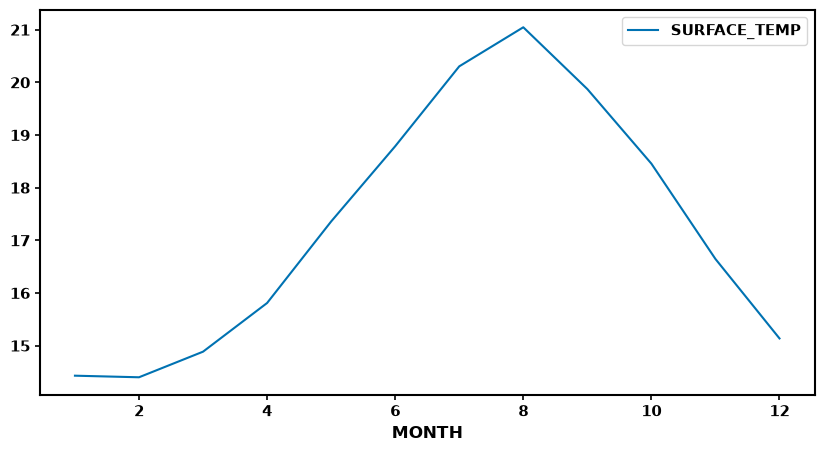

In [11]:
(sea_temp
 .groupby('MONTH') 
 .mean() 
 .plot(kind='line', y='SURFACE_TEMP')
);

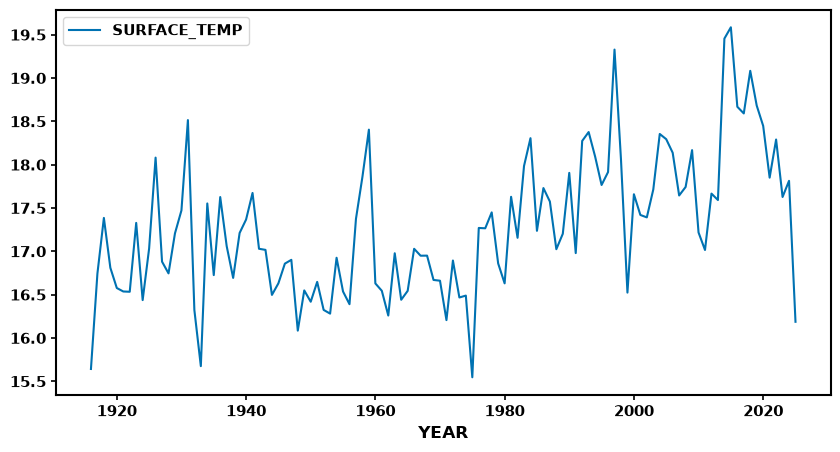

In [12]:
# Why is there a sudden drop at the end? Look at the dates of data collection!
(sea_temp
 .groupby('YEAR') 
 .mean() 
 .plot(kind='line', y='SURFACE_TEMP')
);

### Summary: Grouping on multiple columns

- Pass a list of columns to `.groupby` to group on multiple columns. This creates groups within groups.
- Use `.reset_index()` after grouping on multiple columns to move the MultiIndex back to the columns.

## Merging 🚙

In [13]:
offer_percentage = pd.DataFrame().assign(
    clothing_type=['Shirt', 'Pants', 'Dress', 'Shorts', 'Shoes'],
    offer_percentage=[20, 30, 50, 30, 50]
)

clothes = pd.DataFrame().assign(
    item=['Dress', 'Shirt', 'Shoes', 'Pants', 'Shoes'],
    retail_price=[150, 30, 90, 50, 70]
)

### Example: Clothing Resale 👕

In [14]:
# The percentage of retail price that I can earn for reselling my clothes.
offer_percentage

,clothing_type,offer_percentage
0,Shirt,20
1,Pants,30
2,Dress,50
3,Shorts,30
4,Shoes,50


In [15]:
# The items I want to sell and their retail prices.
clothes

,item,retail_price
0,Dress,150
1,Shirt,30
2,Shoes,90
3,Pants,50
4,Shoes,70


- **Question**: If I sell all of the clothes in my collection, how much will I earn?

- **Issue**: The information I need to answer the question is spread across multiple DataFrames.

### If I sell all of the clothes in my collection, how much will I earn?

In [16]:
clothes_merged = offer_percentage.merge(clothes, left_on='clothing_type', right_on='item')
clothes_merged

,clothing_type,offer_percentage,item,retail_price
0,Shirt,20,Shirt,30
1,Pants,30,Pants,50
2,Dress,50,Dress,150
3,Shoes,50,Shoes,90
4,Shoes,50,Shoes,70


### What just happened!? 🤯

In [17]:
# Click through the presentation that appears.
merging_animation()

### `.merge`

To "merge" two DataFrames:
- Pick a "left" and "right" DataFrame.
- Choose a column from each to "merge on".
```py
left_df.merge(
    right_df, 
    left_on='left_col_name',
    right_on='right_col_name'
)
```
- `left_on` and `right_on` should be column names (they don't have to be the same).
- The resulting DataFrame contains a single row for every match between the two columns.
- Rows in either DataFrame without a match disappear!

### If I sell all of the clothes in my collection, how much will I earn?

In [18]:
clothes_merged = offer_percentage.merge(clothes, left_on='clothing_type', right_on='item')
clothes_merged

,clothing_type,offer_percentage,item,retail_price
0,Shirt,20,Shirt,30
1,Pants,30,Pants,50
2,Dress,50,Dress,150
3,Shoes,50,Shoes,90
4,Shoes,50,Shoes,70


In [19]:
# If I sell all of the clothes in my collection, how much will I earn?
(clothes_merged.get('offer_percentage') / 100 * clothes_merged.get('retail_price')).sum() 

np.float64(176.0)

### Does it matter which DataFrame is the left or right DataFrame? 🤔

In [20]:
offer_percentage.merge(clothes, left_on='clothing_type', right_on='item')

,clothing_type,offer_percentage,item,retail_price
0,Shirt,20,Shirt,30
1,Pants,30,Pants,50
2,Dress,50,Dress,150
3,Shoes,50,Shoes,90
4,Shoes,50,Shoes,70


In [21]:
clothes.merge(offer_percentage, left_on='item', right_on='clothing_type')

,item,retail_price,clothing_type,offer_percentage
0,Dress,150,Dress,50
1,Shirt,30,Shirt,20
2,Shoes,90,Shoes,50
3,Pants,50,Pants,30
4,Shoes,70,Shoes,50


**Answer**: The order of the rows and columns will be different, but the content will be the same.

### Special cases

#### What if the names of the columns we want to merge on are both the same?

Instead of using `left_on='col'` and `right_on='col'`, you can just say `on='col'`.

In [22]:
offer_percentage

,clothing_type,offer_percentage
0,Shirt,20
1,Pants,30
2,Dress,50
3,Shorts,30
4,Shoes,50


In [23]:
clothes_relabeled = clothes.assign(clothing_type=clothes.get('item')).drop(columns=['item'])
clothes_relabeled

,retail_price,clothing_type
0,150,Dress
1,30,Shirt
2,90,Shoes
3,50,Pants
4,70,Shoes


In this example, the column we want to merge on in both DataFrames is named `'clothing_type'`, so we can just use `on='clothing_type'`.

In [24]:
offer_percentage.merge(clothes_relabeled, on='clothing_type')

,clothing_type,offer_percentage,retail_price
0,Shirt,20,30
1,Pants,30,50
2,Dress,50,150
3,Shoes,50,90
4,Shoes,50,70


**Notice**: There's only one column containing the type of clothing now.

#### What if we want to merge using an index instead of a column?

Instead of using `left_on` or `right_on`, use `left_index=True` or `right_index=True`.

In [25]:
offers_by_item = offer_percentage.set_index('clothing_type')
offers_by_item

,offer_percentage
clothing_type,
Shirt,20
Pants,30
Dress,50
Shorts,30
Shoes,50


In [26]:
clothes

,item,retail_price
0,Dress,150
1,Shirt,30
2,Shoes,90
3,Pants,50
4,Shoes,70


In this example, we want to merge using the index in the left DataFrame (`offers_by_item`) and the `item` column in the right DataFrame (`clothes`).

In [27]:
offers_by_item.merge(clothes, left_index=True, right_on='item')

,offer_percentage,item,retail_price
1,20,Shirt,30
3,30,Pants,50
0,50,Dress,150
2,50,Shoes,90
4,50,Shoes,70


### Concept Check ✅

How many rows are in `weather.merge(schools, on='city')`?

    A. 4    B. 5    C. 6    D. 7    E. 8

In [28]:
concept_check()

### Followup activity

How many rows are in `weather.merge(schools, on='state')`?

## Summary, next time

### Summary

- To group on multiple columns, pass a list to `.groupby`.
    - The result has one row for every unique combination of elements in the specified columns.
- To combine information from multiple DataFrames, use `.merge`.
    - When using `.merge`, Python searches for a match between a specified column in each DataFrame and combines the rows with a match.
    - If there are no matches, the row disappears!